In [ ]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 현재 경로 확인
!pwd

In [ ]:
# drive/MyDrive/Colab Notebooks 경로로 변경
%cd drive/MyDrive/'Colab Notebooks'

In [ ]:
!pip install koreanize-matplotlib

# IMPORT

In [135]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from matplotlib import rc
import math
from sklearn.preprocessing import StandardScaler
from random import shuffle

In [2]:
# 시스템에서 사용할 수 있는 한글 폰트 확인
for font in fm.findSystemFonts():
    if 'Nanum' in font or 'Malgun' in font or 'AppleGothic' in font:
        print(font)

# 한글 폰트 경로 설정 
import platform
if platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')  # Windows의 기본 한글 폰트 (맑은 고딕)
elif platform.system() == 'Darwin':  # macOS
    rc('font', family='AppleGothic')  # macOS의 기본 한글 폰트 (애플 고딕)
else:  # Linux
    rc('font', family='NanumGothic')  # Linux에서는 나눔고딕을 사용 (설치 필요)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.titlepad'] = 10

In [94]:
data = pd.read_excel('C:\\Users\\human\\Python-Web\\testdata.xlsx')

In [95]:
data

,ID,개인프로젝트희망,실무경험,학습기간,전공여부,자신있는언어,자신없는언어,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장추천ID,추천이유
0,S01,희망하지 않음,0년,12개월,관련 전공자,"Java, Python","JavaScript, C++",50% 이하,2,3,4,0,S16,성실하고 꼼꼼함
1,S02,희망,1년,6개월,관련 전공자,JavaScript,C++,50% 이하,2,2,5,90,S09,코딩 실력이 뛰어남
2,S03,희망하지 않음,0년,24개월 이상,비전공자,Java,SQL,80% 이하,2,5,3,90,S15,책임감 있고 팀워크가 뛰어남
3,S04,희망하지 않음,3년 이상,6개월,비전공자,"Python, SQL",Java,10% 이하,1,1,5,75,S07,책임감 있고 팀워크가 뛰어남
4,S05,희망하지 않음,1년,18개월,관련 전공자,"C++, JavaScript",Java,10% 이하,3,1,3,65,S12,성실하고 꼼꼼함
5,S06,희망,0년,24개월 이상,비전공자,"Java, C++","SQL, JavaScript",81% 이상,4,3,4,85,S08,협업을 잘함
6,S07,희망하지 않음,0년,12개월,관련 전공자,Java,SQL,81% 이상,5,2,5,100,S05,협업을 잘함
7,S08,희망하지 않음,2년,6개월,비전공자,JavaScript,"C++, Python",50% 이하,2,4,1,80,S03,책임감 있고 팀워크가 뛰어남
8,S09,희망,3년 이상,6개월,관련 전공자,JavaScript,"Python, C++",50% 이하,2,4,2,65,S08,코딩 실력이 뛰어남
9,S10,희망하지 않음,2년,18개월,비전공자,"JavaScript, C++",Python,81% 이상,1,5,1,70,S02,책임감 있고 팀워크가 뛰어남


# 데이터 전처리

## 텍스트 정리
추천 이유 등의 주관식 응답은 분석 제외 또는 워드 클라우드 용도로 처리

In [96]:
# 불필요 항목 제거
data.drop(columns=['개인프로젝트희망', '추천이유'], inplace=True)

In [97]:
data

,ID,실무경험,학습기간,전공여부,자신있는언어,자신없는언어,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장추천ID
0,S01,0년,12개월,관련 전공자,"Java, Python","JavaScript, C++",50% 이하,2,3,4,0,S16
1,S02,1년,6개월,관련 전공자,JavaScript,C++,50% 이하,2,2,5,90,S09
2,S03,0년,24개월 이상,비전공자,Java,SQL,80% 이하,2,5,3,90,S15
3,S04,3년 이상,6개월,비전공자,"Python, SQL",Java,10% 이하,1,1,5,75,S07
4,S05,1년,18개월,관련 전공자,"C++, JavaScript",Java,10% 이하,3,1,3,65,S12
5,S06,0년,24개월 이상,비전공자,"Java, C++","SQL, JavaScript",81% 이상,4,3,4,85,S08
6,S07,0년,12개월,관련 전공자,Java,SQL,81% 이상,5,2,5,100,S05
7,S08,2년,6개월,비전공자,JavaScript,"C++, Python",50% 이하,2,4,1,80,S03
8,S09,3년 이상,6개월,관련 전공자,JavaScript,"Python, C++",50% 이하,2,4,2,65,S08
9,S10,2년,18개월,비전공자,"JavaScript, C++",Python,81% 이상,1,5,1,70,S02


## 중복값 제거
ID 중복 여부 확인 및 제거

In [98]:
print(len(data['ID'].unique()), len(data))  # 전체 데이터 크기 == ID의 unique값 임으로 처리 x

16 16


## 문자열 정규화
“예/아니오” → “1/0”, “3년 이상” → “3” 등 수치형 변환

In [99]:
# 문자열 정규화

data['실무경험'].unique()   # array(['0년', '1년', '3년 이상', '2년'], dtype=object)
data['학습기간'].unique()   # array(['12개월', '6개월', '24개월 이상', '18개월'], dtype=object)
data['전공여부'].unique()   # array(['관련 전공자', '비전공자'], dtype=object)
data['과제완성도'].unique() # array(['50% 이하', '80% 이하', '10% 이하', '81% 이상'], dtype=object)
data['팀장추천ID'].unique() # array(['S16', 'S09', 'S15', 'S07', 'S12', 'S08', 'S05', 'S03', 'S02', 'S04', 'S11'], dtype=object)

array(['S16', 'S09', 'S15', 'S07', 'S12', 'S08', 'S05', 'S03', 'S02',
       'S04', 'S11'], dtype=object)

In [100]:
data['실무경험'].replace({'0년': 0, '1년': 1,'2년': 2, '3년 이상':3}, inplace=True)
data['학습기간'].replace({'6개월': 1, '12개월': 2, '18개월': 3, '24개월 이상': 4}, inplace=True)
data['전공여부'].replace({'관련 전공자': 1, '비전공자':0}, inplace=True)
data['과제완성도'].replace({'10% 이하': 0, '50% 이하': 1, '80% 이하': 2, '81% 이상': 3}, inplace=True)

C:\Users\human\AppData\Local\Temp\ipykernel_10368\3480352163.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['실무경험'].replace({'0년': 0, '1년': 1,'2년': 2, '3년 이상':3}, inplace=True)
C:\Users\human\AppData\Local\Temp\ipykernel_10368\3480352163.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  

## 파생 변수 생성
팀 점수 = 웹점수 + DB점수 + 빅데이터점수 + 과제점수(100→5점)

In [101]:
data['팀장점수'] = 0
for i in range(len(data)):
    temp = data.iloc[i]['팀장추천ID']
    if temp in data['ID'].unique():
        data.loc[data['ID'] == temp, '팀장점수'] += 1
data.drop(columns=['팀장추천ID'], inplace=True)    

In [102]:
data['자신있는언어'].unique()   
# data['자신없는언어'].unique()

array(['Java, Python', 'JavaScript', 'Java', 'Python, SQL',
       'C++, JavaScript', 'Java, C++', 'JavaScript, C++', 'SQL', 'C++',
       'SQL, Java'], dtype=object)

In [103]:
data['front'] = 0
data['back'] = 0
data['deep'] = 0

for i in range(len(data)):
    temp = data.iloc[i]['자신있는언어']
    temp = list(temp.split(','))
    for lang in temp:
        lang = lang.strip()
        if lang in ['Java', 'SQL', 'C++']:
            data.loc[i,'back'] += 1
        elif lang in ['Python']:
            data.loc[i, 'deep'] += 1
        elif lang in ['JavaScript']:
            data.loc[i, 'front'] += 1
    
    temp = data.iloc[i]['자신없는언어']
    temp = list(temp.split(','))
    for lang in temp:
        lang = lang.strip()
        if lang in ['Java', 'SQL', 'C++']:
            data.loc[i, 'back'] -= 1
        elif lang in ['Python']:
            data.loc[i, 'deep'] -= 1
        elif lang in ['JavaScript']:
            data.loc[i, 'front'] -= 1

data.drop(columns=['자신있는언어', '자신없는언어'], inplace=True)

In [104]:
data

,ID,실무경험,학습기간,전공여부,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep
0,S01,0,2,1,1,2,3,4,0,0,-1,0,1
1,S02,1,1,1,1,2,2,5,90,1,1,-1,0
2,S03,0,4,0,2,2,5,3,90,2,0,0,0
3,S04,3,1,0,0,1,1,5,75,2,0,0,1
4,S05,1,3,1,0,3,1,3,65,1,1,0,0
5,S06,0,4,0,3,4,3,4,85,0,-1,1,0
6,S07,0,2,1,3,5,2,5,100,2,0,0,0
7,S08,2,1,0,1,2,4,1,80,3,1,-1,-1
8,S09,3,1,1,1,2,4,2,65,1,1,-1,-1
9,S10,2,3,0,3,1,5,1,70,0,1,1,-1


## 결측치 처리
빈 칸, NULL 값 확인 후 적절히 채우기 (예: 평균값, 최빈값, 제거 등)

In [105]:
# 과제점수가 0점이면 결측치이나 미제출자임으로 0점으로 가눚한 뒤 차후 스케일링에서 비율을 조정

In [106]:
data.isna().sum()   # 결측치 없음으로 보간필요 X

ID        0
실무경험      0
학습기간      0
전공여부      0
과제완성도     0
웹점수       0
빅데이터점수    0
DB점수      0
과제점수      0
팀장점수      0
front     0
back      0
deep      0
dtype: int64

In [ ]:
# 최빈값으로  결측치 보간
for column in data.columns:
    mode_value = data[column].mode()[0]  # 최빈값 계산
    data.fillna({column: mode_value}, inplace=True)

## 범주형 변수 인코딩
전공, 언어, 완성도 등 → 원-핫 인코딩 또는 레이블 인코딩

In [108]:
data    # 따로 인코딩 필요성 없음

,ID,실무경험,학습기간,전공여부,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep
0,S01,0,2,1,1,2,3,4,0,0,-1,0,1
1,S02,1,1,1,1,2,2,5,90,1,1,-1,0
2,S03,0,4,0,2,2,5,3,90,2,0,0,0
3,S04,3,1,0,0,1,1,5,75,2,0,0,1
4,S05,1,3,1,0,3,1,3,65,1,1,0,0
5,S06,0,4,0,3,4,3,4,85,0,-1,1,0
6,S07,0,2,1,3,5,2,5,100,2,0,0,0
7,S08,2,1,0,1,2,4,1,80,3,1,-1,-1
8,S09,3,1,1,1,2,4,2,65,1,1,-1,-1
9,S10,2,3,0,3,1,5,1,70,0,1,1,-1


## 스케일링/정규화
팀 점수 계산을 위한 MinMaxScaler, StandardScaler 적용

In [109]:
data    # 과제점수 스케일링 필요 / 실무경험이 학습기간보다 기간이 긺으로 보정 필요

,ID,실무경험,학습기간,전공여부,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep
0,S01,0,2,1,1,2,3,4,0,0,-1,0,1
1,S02,1,1,1,1,2,2,5,90,1,1,-1,0
2,S03,0,4,0,2,2,5,3,90,2,0,0,0
3,S04,3,1,0,0,1,1,5,75,2,0,0,1
4,S05,1,3,1,0,3,1,3,65,1,1,0,0
5,S06,0,4,0,3,4,3,4,85,0,-1,1,0
6,S07,0,2,1,3,5,2,5,100,2,0,0,0
7,S08,2,1,0,1,2,4,1,80,3,1,-1,-1
8,S09,3,1,1,1,2,4,2,65,1,1,-1,-1
9,S10,2,3,0,3,1,5,1,70,0,1,1,-1


In [110]:
data['실무경험'] *= 2   # 학습기간이 6개월 / 실무경험이 1년 단위임으로 같은 비율로 조정

In [111]:
for i in range(len(data)):
    temp = data.loc[i, '과제점수']
    if temp <= 40:
        data.loc[i, '과제점수'] = 0
    elif temp <= 60:
        data.loc[i, '과제점수'] = 1
    elif temp <= 70:
        data.loc[i, '과제점수'] = 2
    elif temp <= 80:
        data.loc[i, '과제점수'] = 3
    elif temp <= 90:
        data.loc[i, '과제점수'] = 4
    else: 
        data.loc[i, '과제점수'] = 5

In [112]:
data

,ID,실무경험,학습기간,전공여부,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep
0,S01,0,2,1,1,2,3,4,0,0,-1,0,1
1,S02,2,1,1,1,2,2,5,4,1,1,-1,0
2,S03,0,4,0,2,2,5,3,4,2,0,0,0
3,S04,6,1,0,0,1,1,5,3,2,0,0,1
4,S05,2,3,1,0,3,1,3,2,1,1,0,0
5,S06,0,4,0,3,4,3,4,4,0,-1,1,0
6,S07,0,2,1,3,5,2,5,5,2,0,0,0
7,S08,4,1,0,1,2,4,1,3,3,1,-1,-1
8,S09,6,1,1,1,2,4,2,2,1,1,-1,-1
9,S10,4,3,0,3,1,5,1,2,0,1,1,-1


<Axes: >

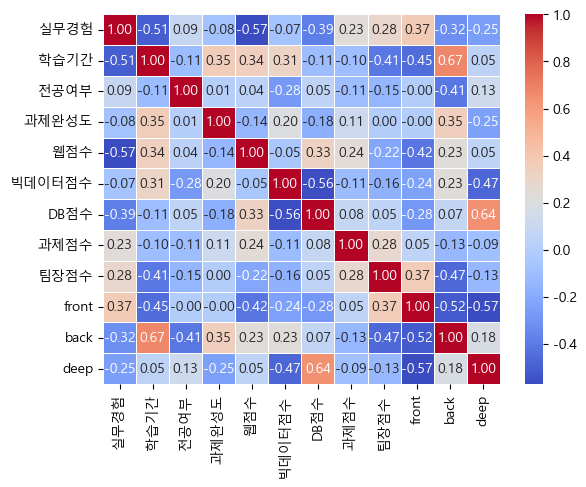

In [113]:
plant_numberic = data.select_dtypes('number')
correlation_matrix = plant_numberic.corr()

plt.Figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# 분석 알고리즘 및 모델

## A. 통계 기반 분석

In [114]:
data

,ID,실무경험,학습기간,전공여부,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep
0,S01,0,2,1,1,2,3,4,0,0,-1,0,1
1,S02,2,1,1,1,2,2,5,4,1,1,-1,0
2,S03,0,4,0,2,2,5,3,4,2,0,0,0
3,S04,6,1,0,0,1,1,5,3,2,0,0,1
4,S05,2,3,1,0,3,1,3,2,1,1,0,0
5,S06,0,4,0,3,4,3,4,4,0,-1,1,0
6,S07,0,2,1,3,5,2,5,5,2,0,0,0
7,S08,4,1,0,1,2,4,1,3,3,1,-1,-1
8,S09,6,1,1,1,2,4,2,2,1,1,-1,-1
9,S10,4,3,0,3,1,5,1,2,0,1,1,-1


In [130]:
dataCollect = pd.DataFrame()
dataCollect['ID'] = data['ID']
dataCollect['front'] = 0
dataCollect['back'] = 0
dataCollect['ai'] = 0
dataCollect['leader'] = 0

dataCollect['front'] += data['웹점수'] * 0.42 + data['front'] + data['실무경험'] * 0.37 + data['학습기간'] * 0.45 + data['전공여부'] * 0 + data['과제완성도'] * 0 + data['과제점수'] * 0.05
dataCollect['back'] += data['DB점수'] * 0.07 + data['back'] + data['실무경험'] * 0.32 + data['학습기간'] * 0.67 + data['전공여부'] * 0.41 + data['과제완성도'] * 0.35 + data['과제점수'] * 0.13
dataCollect['ai'] += data['빅데이터점수'] * 0.47 + data['deep'] + data['실무경험'] * 0.25+ data['학습기간'] * 0.05 + data['전공여부'] * 0.13 + data['과제완성도'] * 0.25 + data['과제점수'] * 0.09
dataCollect['leader'] += data['팀장점수']



In [131]:
dataCollect

,ID,front,back,ai,leader
0,S01,0.74,2.38,2.89,0
1,S02,3.23,1.94,2.23,1
2,S03,2.84,4.11,3.41,2
3,S04,3.24,3.33,3.29,2
4,S05,4.45,3.53,1.43,1
5,S06,2.68,5.53,2.72,0
6,S07,3.25,3.80,2.37,2
7,S08,3.92,1.76,2.45,3
8,S09,4.61,2.75,2.99,1
9,S10,4.35,5.67,3.43,0


<Axes: >

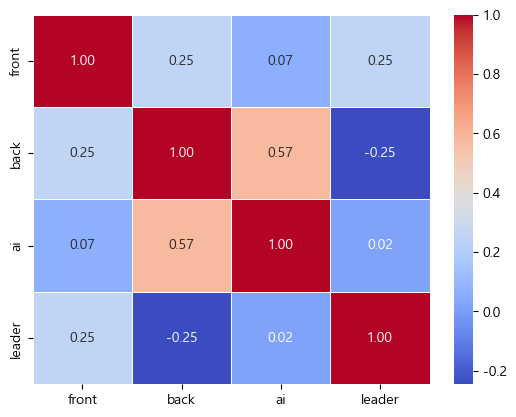

In [132]:
plant_numberic = dataCollect.select_dtypes('number')
correlation_matrix = plant_numberic.corr()

plt.Figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [118]:
data

,ID,실무경험,학습기간,전공여부,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep
0,S01,0,2,1,1,2,3,4,0,0,-1,0,1
1,S02,2,1,1,1,2,2,5,4,1,1,-1,0
2,S03,0,4,0,2,2,5,3,4,2,0,0,0
3,S04,6,1,0,0,1,1,5,3,2,0,0,1
4,S05,2,3,1,0,3,1,3,2,1,1,0,0
5,S06,0,4,0,3,4,3,4,4,0,-1,1,0
6,S07,0,2,1,3,5,2,5,5,2,0,0,0
7,S08,4,1,0,1,2,4,1,3,3,1,-1,-1
8,S09,6,1,1,1,2,4,2,2,1,1,-1,-1
9,S10,4,3,0,3,1,5,1,2,0,1,1,-1


In [122]:
testdata = pd.DataFrame()
testdata = pd.concat([data, dataCollect], axis=1)
testdata

,ID,실무경험,학습기간,전공여부,과제완성도,웹점수,빅데이터점수,DB점수,과제점수,팀장점수,front,back,deep,ID,front,back,ai,leader
0,S01,0,2,1,1,2,3,4,0,0,-1,0,1,S01,1.0,4.0,4.0,0
1,S02,2,1,1,1,2,2,5,4,1,1,-1,0,S02,5.0,4.0,4.0,1
2,S03,0,4,0,2,2,5,3,4,2,0,0,0,S03,4.0,4.0,5.0,2
3,S04,6,1,0,0,1,1,5,3,2,0,0,1,S04,3.0,5.0,4.0,2
4,S05,2,3,1,0,3,1,3,2,1,1,0,0,S05,5.0,4.0,3.0,1
5,S06,0,4,0,3,4,3,4,4,0,-1,1,0,S06,4.0,6.0,5.0,0
6,S07,0,2,1,3,5,2,5,5,2,0,0,0,S07,6.0,6.0,4.0,2
7,S08,4,1,0,1,2,4,1,3,3,1,-1,-1,S08,5.0,2.0,4.0,3
8,S09,6,1,1,1,2,4,2,2,1,1,-1,-1,S09,6.0,4.0,5.0,1
9,S10,4,3,0,3,1,5,1,2,0,1,1,-1,S10,5.0,5.0,5.0,0


<Axes: >

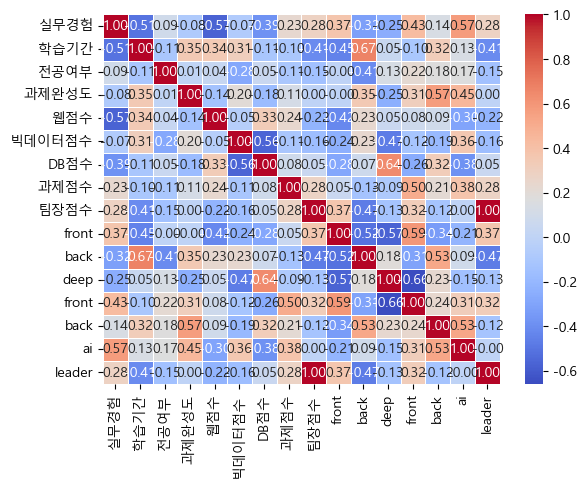

In [126]:
plant_numberic = testdata.select_dtypes('number')
correlation_matrix = plant_numberic.corr()

plt.Figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [157]:
# 각 조의 능력의 편차가 가장 작게 되도록

user = []
for i in range(len(dataCollect)):
    user.append([dataCollect.loc[i, 'ID'], dataCollect.loc[i, 'front'] + dataCollect.loc[i, 'back'] + dataCollect.loc[i, 'ai'], dataCollect.loc[i, 'leader']])

user.sort(key=lambda x : x[1])
# print(user)

avg = sum(x[1] for x in user)/len(user)
# print(avg)

count = math.floor(len(dataCollect) / 3)
left = len(dataCollect) % 3
teamcount = [3 for i in range(count)]
teamscore = []
team = []

for i in range(left):
    teamcount[i] += 1
    
for i in range(count):
    temp = user.pop()
    team.append([temp])
    teamscore.append([temp[1]])
    teamcount[i] -= 1
    
# print(len(team))
# print(len(teamcount))
shuffle(user)

for u in user:
    score = u[1]
    temp_arr = []
    for i in range(count):
        if teamcount[i]:
            # temp_arr.append([i, (sum(x[1] for x in team[i]) + score) / (len(team[i]) + 1)])
            temp_arr.append([i, ((sum(x[1] for x in team[i]) + score) / (len(team[i]) + 1) - avg) ** 2])
    
    temp_arr.sort(key=lambda x : x[1])
    # print(temp_arr)
    team[int(temp_arr[0][0])].append(u)
    teamcount[int(temp_arr[0][0])] -= 1

# print(team)
print([x[0] for x in team[0]], (sum(x[1] for x in team[0])) / (len(team[0])))
print([x[0] for x in team[1]], (sum(x[1] for x in team[1])) / (len(team[1])))
print([x[0] for x in team[2]], (sum(x[1] for x in team[2])) / (len(team[2])))
print([x[0] for x in team[3]], (sum(x[1] for x in team[3])) / (len(team[3])))
print([x[0] for x in team[4]], (sum(x[1] for x in team[4])) / (len(team[4])))

['S16', 'S05', 'S15', 'S07'] 10.602500000000001
['S10', 'S01', 'S04'] 9.773333333333333
['S11', 'S14', 'S02'] 9.106666666666667
['S06', 'S12', 'S09'] 9.856666666666667
['S03', 'S08', 'S13'] 9.146666666666667


## B. 머신러닝/군집화 기반 

## C. 최적화 기반 팀 편성 알고리즘